In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/ml_handoff.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1464, 15)

Columns:
['temperature', 'humidity', 'rainfall', 'pressure', 'wind_speed', 'rainfall_3h', 'rainfall_6h', 'rainfall_12h', 'rainfall_24h', 'hour', 'day_of_week', 'month', 'latitude', 'longitude', 'rainfall_next_1h']

First 5 Rows:


,temperature,humidity,rainfall,pressure,wind_speed,rainfall_3h,rainfall_6h,rainfall_12h,rainfall_24h,hour,day_of_week,month,latitude,longitude,rainfall_next_1h
0,29.1,74,0.1,954.9,5.2,0.1,0.2,1.8,1.9,23,2,7,26.9124,75.7873,4.6
1,26.5,93,4.6,954.8,7.4,4.7,4.7,6.2,6.5,0,3,7,26.9124,75.7873,1.5
2,25.5,94,1.5,954.0,11.1,6.2,6.2,7.6,8.0,1,3,7,26.9124,75.7873,1.4
3,25.4,94,1.4,953.7,7.4,7.5,7.6,8.9,9.4,2,3,7,26.9124,75.7873,1.9
4,24.9,96,1.9,954.0,6.3,4.8,9.5,10.0,11.3,3,3,7,26.9124,75.7873,1.7



Missing Values:
temperature         0
humidity            0
rainfall            0
pressure            0
wind_speed          0
rainfall_3h         0
rainfall_6h         0
rainfall_12h        0
rainfall_24h        0
hour                0
day_of_week         0
month               0
latitude            0
longitude           0
rainfall_next_1h    0
dtype: int64


In [2]:
# Target column
target = "rainfall_next_1h"

# Input features
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

print("Number of features:", len(features))
print("\nFeatures:")
print(features)

print("\nTarget:")
print(target)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Number of features: 14

Features:
['temperature', 'humidity', 'rainfall', 'pressure', 'wind_speed', 'rainfall_3h', 'rainfall_6h', 'rainfall_12h', 'rainfall_24h', 'hour', 'day_of_week', 'month', 'latitude', 'longitude']

Target:
rainfall_next_1h

X shape: (1464, 14)
y shape: (1464,)


In [3]:
# Chronological 80/20 train-test split

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (1171, 14)
Testing data: (293, 14)

Training target: (1171,)
Testing target: (293,)


In [4]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


In [5]:
# Make predictions on test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predictions:
[0.0085 0.0365 0.     0.004  0.0005 0.004  0.     0.     0.     0.    ]


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation Results
------------------------
MAE : 0.103240614334471
RMSE: 0.3268847515332934
R²  : -0.37968099815155765


In [7]:
print("Rainfall target statistics:")
print(y.describe())

print("\nZero rainfall records:")
print((y == 0).sum())

print("\nNon-zero rainfall records:")
print((y > 0).sum())

Rainfall target statistics:
count    1464.000000
mean        0.179235
std         0.714429
min         0.000000
25%         0.000000
50%         0.000000
75%         0.100000
max        14.300000
Name: rainfall_next_1h, dtype: float64

Zero rainfall records:
1043

Non-zero rainfall records:
421


In [8]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Transform target
y_train_log = np.log1p(y_train)

# Train improved model
model_log = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model_log.fit(X_train, y_train_log)

# Predict
y_pred_log = model_log.predict(X_test)

# Convert predictions back to rainfall in mm
y_pred_improved = np.expm1(y_pred_log)

# Avoid negative rainfall predictions
y_pred_improved = np.maximum(y_pred_improved, 0)

# Evaluate
mae_improved = mean_absolute_error(y_test, y_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_improved))
r2_improved = r2_score(y_test, y_pred_improved)

print("Improved Model Results")
print("---------------------")
print("MAE :", mae_improved)
print("RMSE:", rmse_improved)
print("R²  :", r2_improved)

Improved Model Results
---------------------
MAE : 0.08207312708439611
RMSE: 0.2767509800141257
R²  : 0.0110651229553973


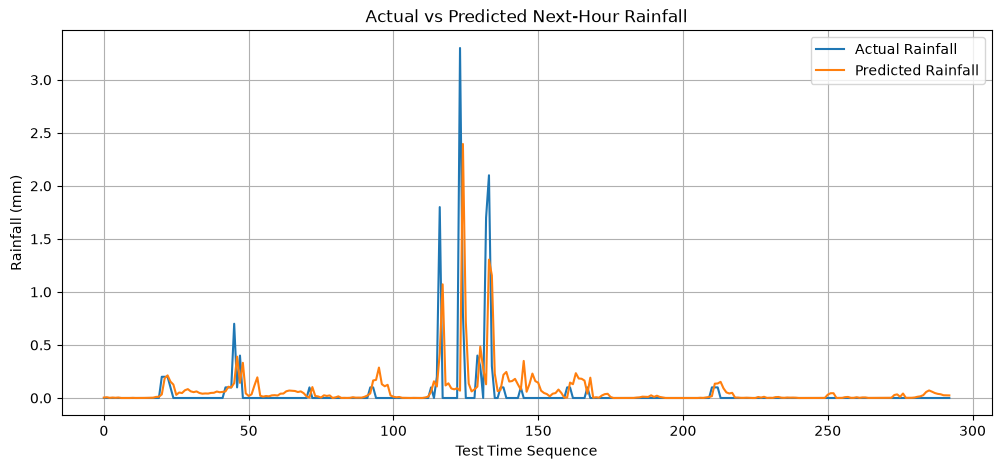

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values,
    label="Actual Rainfall"
)

plt.plot(
    y_pred_improved,
    label="Predicted Rainfall"
)

plt.xlabel("Test Time Sequence")
plt.ylabel("Rainfall (mm)")
plt.title("Actual vs Predicted Next-Hour Rainfall")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
import joblib

# Save the improved rainfall prediction model
joblib.dump(model_log, "../models/rainfall_next_1h_model.pkl")

print("Rainfall prediction model saved successfully!")

Rainfall prediction model saved successfully!


In [11]:
# Load rain/no-rain classification dataset

df_class = pd.read_csv("../data/processed/ml_classification_handoff.csv")

print("Dataset Shape:", df_class.shape)

print("\nColumns:")
print(df_class.columns.tolist())

print("\nFirst 5 Rows:")
display(df_class.head())

print("\nMissing Values:")
print(df_class.isnull().sum())

Dataset Shape: (1463, 15)

Columns:
['temperature', 'humidity', 'rainfall', 'pressure', 'wind_speed', 'rainfall_3h', 'rainfall_6h', 'rainfall_12h', 'rainfall_24h', 'hour', 'day_of_week', 'month', 'latitude', 'longitude', 'rain_next_1h_flag']

First 5 Rows:


,temperature,humidity,rainfall,pressure,wind_speed,rainfall_3h,rainfall_6h,rainfall_12h,rainfall_24h,hour,day_of_week,month,latitude,longitude,rain_next_1h_flag
0,29.1,74,0.1,954.9,5.2,0.1,0.2,1.8,1.9,23,2,7,26.9124,75.7873,1
1,26.5,93,4.6,954.8,7.4,4.7,4.7,6.2,6.5,0,3,7,26.9124,75.7873,1
2,25.5,94,1.5,954.0,11.1,6.2,6.2,7.6,8.0,1,3,7,26.9124,75.7873,1
3,25.4,94,1.4,953.7,7.4,7.5,7.6,8.9,9.4,2,3,7,26.9124,75.7873,1
4,24.9,96,1.9,954.0,6.3,4.8,9.5,10.0,11.3,3,3,7,26.9124,75.7873,1



Missing Values:
temperature          0
humidity             0
rainfall             0
pressure             0
wind_speed           0
rainfall_3h          0
rainfall_6h          0
rainfall_12h         0
rainfall_24h         0
hour                 0
day_of_week          0
month                0
latitude             0
longitude            0
rain_next_1h_flag    0
dtype: int64


In [12]:
# Separate features and target

target_class = "rain_next_1h_flag"

features_class = [col for col in df_class.columns if col != target_class]

X_class = df_class[features_class]
y_class = df_class[target_class]

print("Number of features:", len(features_class))

print("\nFeatures:")
print(features_class)

print("\nTarget:")
print(target_class)

print("\nX shape:", X_class.shape)
print("y shape:", y_class.shape)

print("\nClass distribution:")
print(y_class.value_counts())

Number of features: 14

Features:
['temperature', 'humidity', 'rainfall', 'pressure', 'wind_speed', 'rainfall_3h', 'rainfall_6h', 'rainfall_12h', 'rainfall_24h', 'hour', 'day_of_week', 'month', 'latitude', 'longitude']

Target:
rain_next_1h_flag

X shape: (1463, 14)
y shape: (1463,)

Class distribution:
rain_next_1h_flag
0    1042
1     421
Name: count, dtype: int64


In [13]:
# Chronological 80/20 train-test split

split_class = int(len(df_class) * 0.80)

X_class_train = X_class.iloc[:split_class]
X_class_test = X_class.iloc[split_class:]

y_class_train = y_class.iloc[:split_class]
y_class_test = y_class.iloc[split_class:]

print("Training data:", X_class_train.shape)
print("Testing data:", X_class_test.shape)

print("\nTraining target:", y_class_train.shape)
print("Testing target:", y_class_test.shape)

print("\nTraining class distribution:")
print(y_class_train.value_counts())

print("\nTesting class distribution:")
print(y_class_test.value_counts())

Training data: (1170, 14)
Testing data: (293, 14)

Training target: (1170,)
Testing target: (293,)

Training class distribution:
rain_next_1h_flag
0    781
1    389
Name: count, dtype: int64

Testing class distribution:
rain_next_1h_flag
0    261
1     32
Name: count, dtype: int64


In [14]:
from sklearn.ensemble import RandomForestClassifier

# Create classification model
classifier = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train the model
classifier.fit(X_class_train, y_class_train)

print("Rain/No-Rain classification model trained successfully!")

Rain/No-Rain classification model trained successfully!


In [15]:
# Make predictions on test data

y_class_pred = classifier.predict(X_class_test)

print("Classification predictions generated successfully!")

print("\nFirst 20 predictions:")
print(y_class_pred[:20])

Classification predictions generated successfully!

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_class_test, y_class_pred)
precision = precision_score(y_class_test, y_class_pred, zero_division=0)
recall = recall_score(y_class_test, y_class_pred, zero_division=0)
f1 = f1_score(y_class_test, y_class_pred, zero_division=0)

print("Classification Model Evaluation")
print("--------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(
    y_class_test,
    y_class_pred,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_class_test, y_class_pred))

Classification Model Evaluation
--------------------------------
Accuracy : 0.8805460750853242
Precision: 0.45714285714285713
Recall   : 0.5
F1 Score : 0.47761194029850745

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       261
           1       0.46      0.50      0.48        32

    accuracy                           0.88       293
   macro avg       0.70      0.71      0.71       293
weighted avg       0.89      0.88      0.88       293


Confusion Matrix:
[[242  19]
 [ 16  16]]


In [17]:
import joblib

# Save Rain/No-Rain classification model
joblib.dump(
    classifier,
    "../models/rain_classification_model.pkl"
)

print("Rain/No-Rain classification model saved successfully!")

Rain/No-Rain classification model saved successfully!


In [18]:
# Test with a new weather condition

new_weather = pd.DataFrame([{
    "temperature": 28.0,
    "humidity": 85,
    "rainfall": 2.0,
    "pressure": 950.0,
    "wind_speed": 12.0,
    "rainfall_3h": 5.0,
    "rainfall_6h": 8.0,
    "rainfall_12h": 10.0,
    "rainfall_24h": 15.0,
    "hour": 15,
    "day_of_week": 3,
    "month": 8,
    "latitude": 26.9124,
    "longitude": 75.7873
}])

# Rain / No-Rain prediction
rain_flag = classifier.predict(new_weather)[0]

# Next-hour rainfall prediction
rainfall_prediction = model_log.predict(new_weather)[0]
rainfall_prediction = max(np.expm1(rainfall_prediction), 0)

print("Weather Prediction")
print("------------------")

if rain_flag == 1:
    print("Rain Prediction: RAIN")
else:
    print("Rain Prediction: NO RAIN")

print("Predicted Next-Hour Rainfall:", round(rainfall_prediction, 2), "mm")

Weather Prediction
------------------
Rain Prediction: RAIN
Predicted Next-Hour Rainfall: 0.53 mm


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
importance = classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Weather Feature Importance for Rain Prediction")
plt.gca().invert_yaxis()

plt.show()